In [46]:
import os
import json

import pandas as pd 
import numpy as np 

import joblib
import matplotlib.pyplot as plt

In [2]:
data_dir_path = "../data/realAWSCloudwatch"
dfs = {}

for filename in os.listdir(data_dir_path):
    if filename.startswith("ec2_cpu_utilization"):
        df = pd.read_csv(os.path.join(data_dir_path, filename))
        dfs[filename] = df

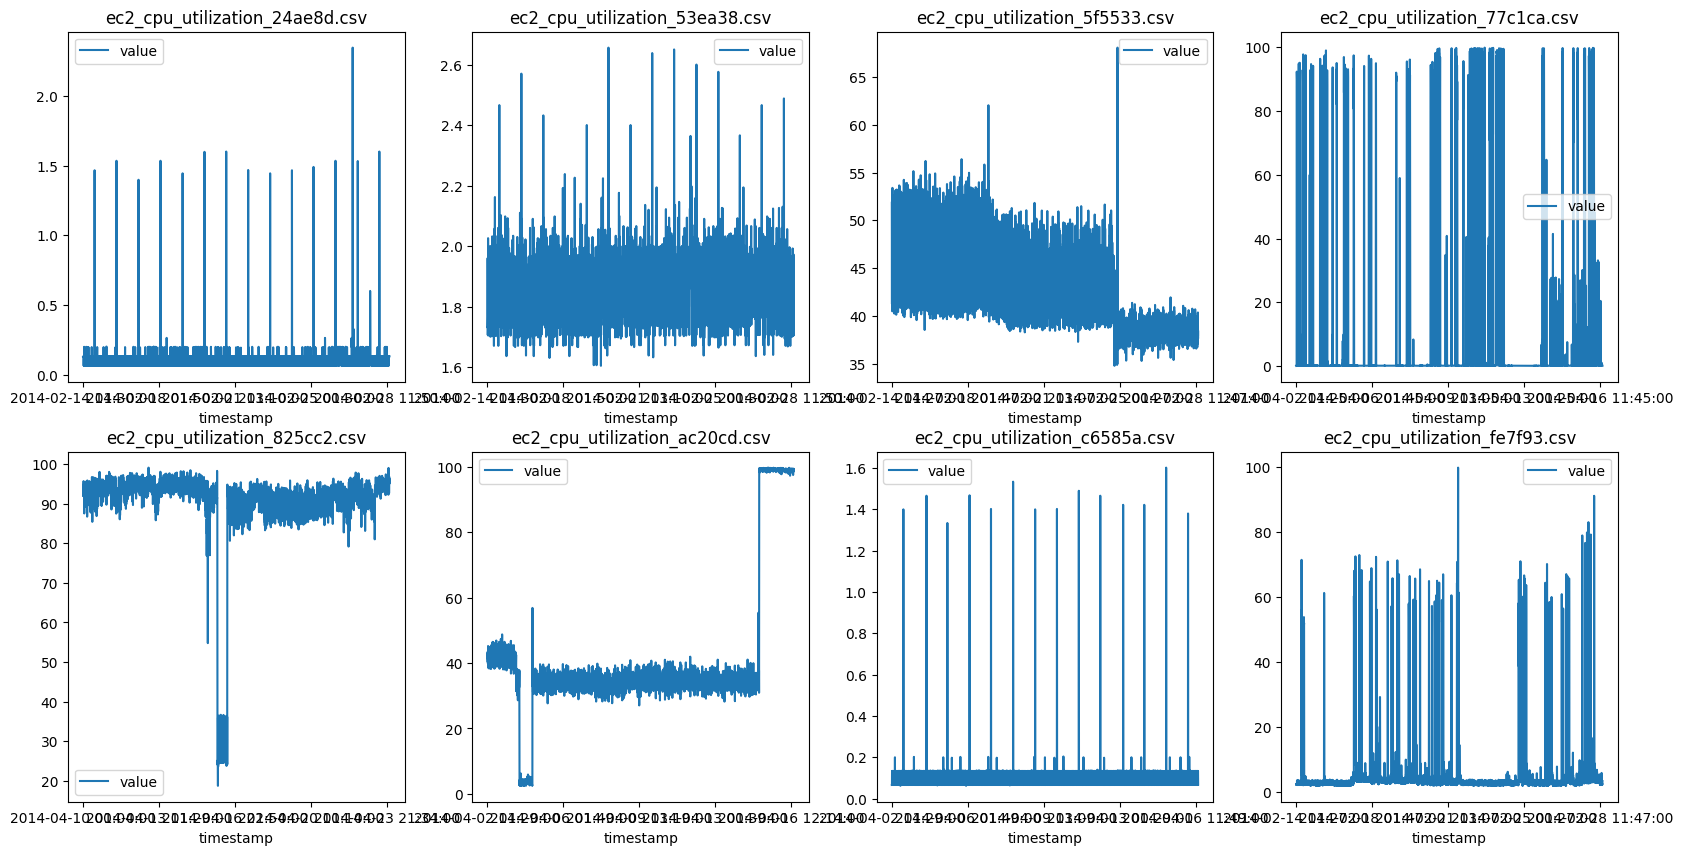

In [49]:
fig, axs = plt.subplots(2, 4, figsize=(20, 10))
axs.flat

for i, filename in enumerate(dfs.keys()):
    df = dfs[filename]
    df.plot(x="timestamp", y="value", ax=axs.flat[i], title=filename)

plt.show()

The cpu utilization data have very different patterns

In [ ]:
#TO-DO: Add anomaly labels to the dataframes

In [ ]:
#TO-DO: make the plott show anomalies on right timestamps

labels_path = "../data/labels/combined_labels.json"

with open(labels_path, "r") as f:
    labels = json.load(f)

fig, axs = plt.subplots(2, 4, figsize=(20, 10))

for i, filename in enumerate(dfs.keys()):
    df = dfs[filename]
    df.plot(x="timestamp", y="value", ax=axs.flat[i], title=filename)
    anomalies = df[df['anomaly_label'] == 1]
    anomalies.plot.scatter(x="timestamp", y="value", ax=axs.flat[i], color='red', label='Anomalies')
    axs.flat[i].legend()

plt.show()

['2014-02-26 22:05:00', '2014-02-27 17:15:00']


TypeError: 'method' object is not subscriptable